# Stock Price Prediction — ML Final Project

## Project Overview
This project builds and compares **six machine learning models** to predict the **next-day closing price** of Apple (AAPL) stock using historical data from 2017–2019.

| Property | Value |
|---|---|
| **Data Source** | Yahoo Finance (yfinance) |
| **Stocks** | AAPL, TSLA, AMZN, V, MSFT |
| **Period** | Jan 2017 – Dec 2019 (~754 trading days) |
| **Target** | Tomorrow's closing price |

### Models Compared
| Category | Models |
|---|---|
| Linear | Linear Regression |
| Tree-based Ensemble | Random Forest, Decision Tree, XGBoost |
| Deep Learning | Simple RNN, LSTM |

### Full Pipeline
1. Load and clean historical closing prices
2. Exploratory Data Analysis — trends, sector breakdown, correlations
3. Feature engineering — lagged returns, moving averages, volatility
4. Scaling with `StandardScaler` (fit on training data only)
5. Naive baseline (random walk) for benchmarking
6. Train and evaluate all six models
7. Feature importance analysis
8. Time-series cross-validation
9. Residual analysis

## Section 1: Data Loading

**What this cell does:**
- Imports all required libraries for data handling, visualization, and machine learning
- Downloads closing prices for 5 S&P 500 stocks from Yahoo Finance using `yfinance`
- Saves results to `prices_cache.csv` so the API is only called **once** — subsequent runs load from disk
- `HAS_TF` flag checks whether TensorFlow is installed; if not, RNN/LSTM cells are gracefully skipped
- The preview shows raw data with one row per trading day

In [ ]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("TensorFlow not available — RNN/LSTM cells will be skipped.")

STOCK_DICT = {'Apple': 'AAPL', 'Tesla': 'TSLA', 'Amazon': 'AMZN', 'Visa': 'V', 'Microsoft': 'MSFT'}
START      = '2017-1-1'
END        = '2019-12-31'
CACHE_FILE = Path('prices_cache.csv')

if CACHE_FILE.exists():
    raw_df = pd.read_csv(CACHE_FILE)
else:
    symbol_to_name = {v: k for k, v in STOCK_DICT.items()}
    downloaded = yf.download(
        tickers=list(STOCK_DICT.values()),
        start=START, end=END,
        progress=False, auto_adjust=False
    )['Close']
    raw_df = downloaded.rename(columns=symbol_to_name).reset_index()
    raw_df.to_csv(CACHE_FILE, index=False)

raw_df = raw_df[['Date'] + list(STOCK_DICT.keys())]
raw_df.head()

## Section 2: Data Cleaning

**What this cell does — cleaning steps in order:**
1. **Parse dates** — converts the `Date` column to proper `datetime` objects; invalid dates become `NaT`
2. **Drop invalid dates** — removes any rows where the date couldn't be parsed
3. **Normalize timestamps** — strips the time component (stock data has no intraday time)
4. **Deduplicate** — keeps only the first record if the same date appears twice
5. **Sort chronologically** — essential for time-series integrity before splitting
6. **Set date as index** — makes the date the row label for clean plotting and indexing
7. **Convert prices to numeric** — forces float conversion; non-numeric values become `NaN`
8. **Drop incomplete rows** — removes any row with a missing price in any column

In [ ]:
df = raw_df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Date'] = df['Date'].dt.normalize()
df = df.drop_duplicates(subset=['Date'], keep='first')
df = df.sort_values('Date').set_index('Date')
for col in STOCK_DICT.keys():
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(how='any')
print(f"Clean dataset: {df.shape[0]} trading days, {df.shape[1]} stocks")
df.head()

## Section 3: Exploratory Data Analysis (EDA)

EDA helps us understand patterns, scale differences, and relationships in the data **before** modeling. Key questions:
- How do prices trend over time?
- Which stocks are most correlated?
- How are returns distributed?

### 3a. Log Returns

**What this cell does:**
Log return = ln(today's price / yesterday's price)

- More statistically well-behaved than raw percentage returns
- **Additive over time**: a 5-day log return = sum of 5 daily log returns
- Approximately normally distributed, which suits statistical analysis
- Used here for EDA only — the ML models later use percentage-change features (`pct_change`)

In [ ]:
df_logreturn = np.log(df / df.shift(1)).dropna()
df_logreturn.head()

### 3b. Closing Price Trends

**What this cell does:** Plots all 5 stocks on a single chart to visualize long-term price trends.

**Key observations:**
- Apple and Microsoft show steady upward growth — consistent with S&P 500 bull market
- Tesla is highly volatile with sharp price swings
- Amazon trades at much higher price levels (~$1,000–$2,000)
- Different price scales confirm why **StandardScaler** is necessary before modeling

In [ ]:
plt.figure(figsize=(14, 6))
for col in df.columns:
    plt.plot(df[col], label=col)
plt.title("Closing Prices of Selected S&P 500 Stocks (2017–2019)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

### 3c. Sector Analysis

**What this cell does:** Creates a manual sector/market-cap dataset for the 5 stocks and visualizes:
1. **Count plot** — how many stocks per sector
2. **Donut chart** — market cap share by sector

**Insight:** Technology (AAPL + MSFT) dominates by market cap. Consumer Cyclical (TSLA + AMZN) has two stocks but very different behaviors — TSLA is volatile, AMZN is steadily growing.

In [ ]:
sector_data = {
    'Symbol':    ['AAPL',  'TSLA',              'AMZN',              'V',                  'MSFT'],
    'Company':   ['Apple', 'Tesla',             'Amazon',            'Visa',               'Microsoft'],
    'Sector':    ['Technology', 'Consumer Cyclical', 'Consumer Cyclical', 'Financial Services', 'Technology'],
    'Marketcap': [3e12,    0.8e12,              1.5e12,              0.5e12,               3.2e12]
}
df_sector = pd.DataFrame(sector_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    x='Sector', data=df_sector,
    order=df_sector['Sector'].value_counts().index,
    palette='viridis', ax=axes[0]
)
axes[0].bar_label(axes[0].containers[0], label_type='edge')
axes[0].set_title('Companies per Sector', fontsize=14)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
secm    = df_sector.groupby('Sector')['Marketcap'].sum().reset_index()
percent = 100 * (secm['Marketcap'] / secm['Marketcap'].sum())
colors  = ['orange', 'red', 'green']
patches, _ = axes[1].pie(
    secm['Marketcap'], colors=colors, startangle=90,
    wedgeprops=dict(width=0.4)
)
labels = [f"{s}: {p:.1f}%" for s, p in zip(secm['Sector'], percent)]
axes[1].legend(patches, labels, loc='center left',
               bbox_to_anchor=(1.0, 0.5), fontsize=11, title='Sector')
axes[1].set_title('Market Cap Share by Sector', fontsize=14)
plt.tight_layout()
plt.show()
df_sector

### 3d. Correlation Heatmap

**What this cell does:** Computes and visualizes the pairwise Pearson correlation of closing prices.

**How to read it:**
- Values near **+1.0** = stocks move almost perfectly together
- Values near **0** = no linear relationship

**Key insight:** High correlations across the board reflect that all 5 stocks belong to the S&P 500 and are exposed to the same broad market movements (bull market 2017–2019). Apple ↔ Microsoft tend to be the most correlated because both are large-cap technology.

In [ ]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Closing Prices", fontsize=14)
plt.show()

## Section 4: Feature Engineering

**What this cell does:**
Builds 11 input features from the Apple price series. Features are designed to give models signals across three categories:

| Feature | Type | Description |
|---|---|---|
| `Price` | Raw | Today's closing price (USD) |
| `Return_1` … `Return_5` | Momentum | % price change over past 1–5 days |
| `SMA_5` | Trend | 5-day simple moving average |
| `SMA_10` | Trend | 10-day simple moving average |
| `SMA_ratio` | Trend | SMA_5 / SMA_10 — values > 1 = short-term bullish |
| `Volatility_5` | Risk | Rolling 5-day std of daily returns |
| `Momentum` | Trend | Price relative to 10-day average |

**Target:** `Price.shift(-1)` — tomorrow's closing price (the value we want to predict)

The first 10 rows are dropped because rolling windows and `pct_change` need at least 10 days of history.

In [ ]:
target_stock = 'Apple'
ml_df = df[[target_stock]].copy().rename(columns={target_stock: 'Price'})
ml_df['Target'] = ml_df['Price'].shift(-1)
for i in range(1, 6):
    ml_df[f'Return_{i}'] = ml_df['Price'].pct_change(i)
ml_df['SMA_5']       = ml_df['Price'].rolling(5).mean()
ml_df['SMA_10']      = ml_df['Price'].rolling(10).mean()
ml_df['SMA_ratio']   = ml_df['SMA_5'] / ml_df['SMA_10']
ml_df['Volatility_5']= ml_df['Price'].pct_change().rolling(5).std()
ml_df['Momentum']    = ml_df['Price'] / ml_df['Price'].rolling(10).mean() - 1
ml_df.dropna(inplace=True)
print(f"Dataset: {ml_df.shape[0]} rows × {ml_df.shape[1]} columns")
ml_df.head()

## Section 5: Train/Test Split and Feature Scaling

**What this cell does:**
1. **Defines the feature matrix `X`** and target vector `y`
2. **Splits 80/20** with `shuffle=False` — preserving temporal order is critical; shuffling would let the model train on future data
3. **Applies `StandardScaler`** — subtracts mean and divides by std so all features have equal scale

**Why `StandardScaler` matters:**
- `Price` (~$30–$300) and `Return_1` (~0.01–0.05) live on completely different scales
- Without scaling, distance-sensitive and gradient-based models weight `Price` 1000× more than returns
- **Critical rule:** the scaler is fit ONLY on training data — fitting on the full dataset would "leak" statistics about future prices

In [ ]:
FEATURE_COLS = [
    'Price',
    'Return_1', 'Return_2', 'Return_3', 'Return_4', 'Return_5',
    'SMA_5', 'SMA_10', 'SMA_ratio', 'Volatility_5', 'Momentum'
]
X = ml_df[FEATURE_COLS]
y = ml_df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
plt.figure(figsize=(14, 4))
plt.plot(y.values, label='Full Dataset', color='steelblue')
plt.axvline(len(y_train), color='red', linestyle='--', label='Train/Test Split (80%)')
plt.title(f'{target_stock} — Train/Test Split')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Section 6: Naive Baseline

**What this cell does:** Creates the simplest possible forecast — predict that **tomorrow's price equals today's price** (the random walk hypothesis).

**Why we need a baseline:**
- Stock prices are highly autocorrelated, so even a trivial model can achieve decent metrics
- Any model that performs *worse* than the naive baseline is effectively useless
- The baseline MAE and R² define the **minimum acceptable threshold** every model must beat

In [ ]:
naive_pred = X_test['Price'].values
naive_mae  = mean_absolute_error(y_test, naive_pred)
naive_r2   = r2_score(y_test, naive_pred)

print(f"Naive Baseline  MAE : {naive_mae:.4f}")
print(f"Naive Baseline  R²  : {naive_r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=3, color='black')
plt.plot(naive_pred, label='Naive (today = tomorrow)', linestyle=':', color='gray')
plt.title(f'{target_stock} — Naive Baseline vs Actual')
plt.xlabel('Test Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Section 7: Machine Learning Models

All four tabular models below are trained on the same `X_train_scaled` / `X_test_scaled` split for a fair comparison. Each model is evaluated with:
- **MAE (Mean Absolute Error)** — average prediction error in USD; lower is better
- **R² Score** — proportion of variance explained; 1.0 is perfect, negative means worse than predicting the mean

### 7a. Linear Regression

**How it works:** Fits a straight-line relationship between features and the target by minimizing the sum of squared errors. Each feature gets a coefficient (weight) reflecting its contribution.

**Why it often works well for stock prices:** Closing prices are strongly autocorrelated — today's price is the single strongest predictor of tomorrow's price. Linear Regression captures this efficiently without overfitting.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)
print(f"Linear Regression  MAE : {lr_mae:.4f}")
print(f"Linear Regression  R²  : {lr_r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=3)
plt.plot(lr_pred, label='Linear Regression', linestyle='--')
plt.title(f'{target_stock} — Linear Regression')
plt.xlabel('Test Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### 7b. Random Forest

**How it works:** Builds `n_estimators=120` decision trees, each trained on a random subset of samples and features. Final prediction = average of all trees. Averaging reduces variance compared to any single tree.

**Hyperparameter choices:**
- `n_estimators=120` — enough trees for stable predictions without excessive runtime
- `max_depth=None` — trees grow fully; regularization comes from `min_samples_split` instead
- `random_state=42` — ensures reproducibility

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=None, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)
print(f"Random Forest  MAE : {rf_mae:.4f}")
print(f"Random Forest  R2  : {rf_r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=3)
plt.plot(rf_pred, label='Random Forest', linestyle='--')
plt.title(f'{target_stock} - Random Forest')
plt.xlabel('Test Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### 7c. Decision Tree

**How it works:** Recursively splits the data on the feature that best reduces prediction error at each node, building a binary tree. Prediction at a leaf = average of all training samples that reach that leaf.

**Hyperparameter choices:**
- `max_depth=5` — prevents the tree from memorizing training noise (overfitting)
- `min_samples_leaf=5` — each leaf must contain ≥5 training samples, making predictions more robust
- `criterion='squared_error'` — splits are chosen to minimize mean squared error

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    criterion='squared_error', max_depth=5,
    min_samples_split=10, min_samples_leaf=5, random_state=42
)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)
print(f"Decision Tree  MAE : {dt_mae:.4f}")
print(f"Decision Tree  R²  : {dt_r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=3)
plt.plot(dt_pred, label='Decision Tree', linestyle='--')
plt.title(f'{target_stock} — Decision Tree')
plt.xlabel('Test Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### 7d. XGBoost

**How it works:** Builds trees *sequentially* — each new tree corrects the residual errors of all previous trees (gradient boosting). This often outperforms Random Forest on tabular data because it directly targets remaining errors rather than averaging independent trees.

**Hyperparameter choices:**
- `n_estimators=200, learning_rate=0.05` — many small-step trees; slow learning rate prevents any single tree from dominating
- `max_depth=3` — shallow trees reduce overfitting; a well-known best practice for gradient boosting
- `subsample=0.9, colsample_bytree=0.8` — adds randomness (like Random Forest) to further reduce variance

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    subsample=0.9, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42, n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2  = r2_score(y_test, xgb_pred)
print(f"XGBoost  MAE : {xgb_mae:.4f}")
print(f"XGBoost  R2  : {xgb_r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=3)
plt.plot(xgb_pred, label='XGBoost', linestyle='--')
plt.title(f'{target_stock} - XGBoost')
plt.xlabel('Test Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Section 8: Feature Importance

**What this cell does:** Visualizes which input features most influenced predictions in Random Forest and XGBoost.

**How to read it:**
- Higher bar = the model relied on that feature more when making predictions
- If `Price` dominates, the models are essentially learning a near-random-walk pattern (price autocorrelation)
- If engineered features (SMA, volatility, momentum) score highly, they are adding real predictive value beyond raw price

In [ ]:
feat_imp_rf  = pd.Series(rf.feature_importances_,  index=FEATURE_COLS).sort_values()
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance Score')

feat_imp_xgb.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance Score')
plt.suptitle('Feature Importance: Random Forest vs XGBoost', fontsize=14)
plt.tight_layout()
plt.show()
print(f"RF   top feature: {feat_imp_rf.index[-1]}  ({feat_imp_rf.values[-1]:.4f})")
print(f"XGB  top feature: {feat_imp_xgb.index[-1]}  ({feat_imp_xgb.values[-1]:.4f})")

## Section 9: Time-Series Cross-Validation

**What this cell does:** Evaluates all four tabular models using **5-fold TimeSeriesSplit** instead of a single 80/20 split.

**Why this matters:**
A single train/test split can give misleading results — a model might look great on one particular test window by luck. `TimeSeriesSplit` performs **walk-forward validation**:

```
Fold 1: [Train────] [Val]
Fold 2: [Train────────] [Val]
Fold 3: [Train────────────] [Val]
...
```

Each fold's validation set is always **in the future** relative to the training set. The **mean MAE ± std** across 5 folds reveals whether a model is consistently accurate or just lucky on one window.

Note: A fresh `StandardScaler` is fit inside each fold to prevent leakage.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
tscv = TimeSeriesSplit(n_splits=3)
cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Decision Tree':     DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42, n_jobs=-1),
}
print(f"{'Model':<22}  {'Mean MAE':>10}  {'Std MAE':>8}")
print("-" * 46)
cv_summary = {}
for name, model in cv_models.items():
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        cv_sc = StandardScaler()
        Xtr = cv_sc.fit_transform(X.iloc[tr_idx])
        Xvl = cv_sc.transform(X.iloc[val_idx])
        model.fit(Xtr, y.iloc[tr_idx])
        scores.append(mean_absolute_error(y.iloc[val_idx], model.predict(Xvl)))
    cv_summary[name] = (np.mean(scores), np.std(scores))
    print(f"{name:<22}  {np.mean(scores):>10.4f}  {np.std(scores):>8.4f}")

plt.figure(figsize=(9, 5))
means = [v[0] for v in cv_summary.values()]
stds  = [v[1] for v in cv_summary.values()]
plt.bar(cv_summary.keys(), means, yerr=stds, capsize=5,
        color=['steelblue', 'forestgreen', 'darkorange', 'crimson'], edgecolor='black')
plt.title('3-Fold TimeSeriesSplit - Mean MAE (+/- Std)')
plt.ylabel('MAE (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

NameError: name 'TimeSeriesSplit' is not defined

## Section 10: Residual Analysis

**What this cell does:** Analyzes prediction errors (residuals = actual − predicted) for all four tabular models.

**Two diagnostic plots:**
1. **Residual histograms** — checks for bias. A good model has residuals centered near zero with a symmetric distribution
2. **Residuals vs Fitted** — checks for heteroscedasticity (error size growing with price). A good model shows a horizontal scatter with no pattern

**Red dashed line** = zero (perfect prediction). The mean residual (red solid line in histograms) quantifies systematic over- or under-prediction.

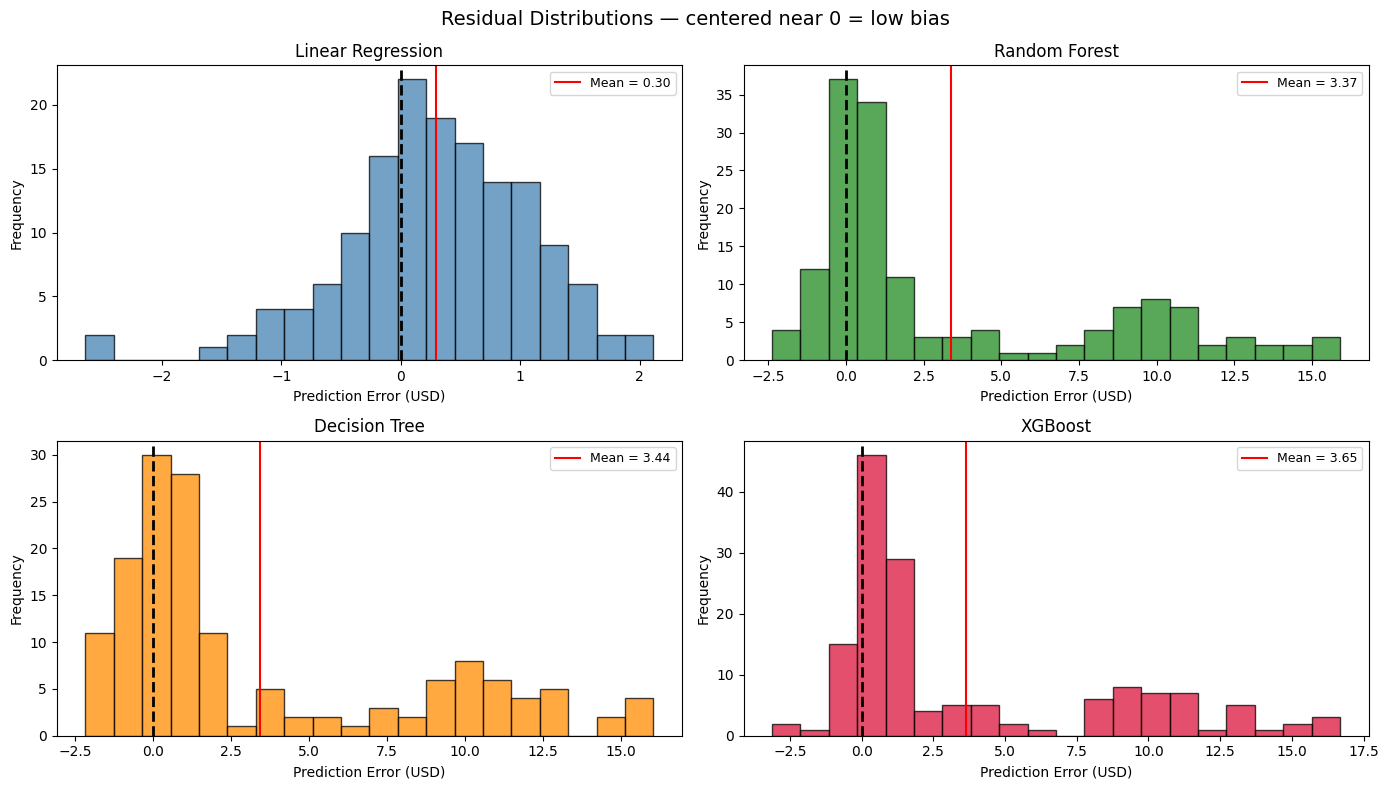

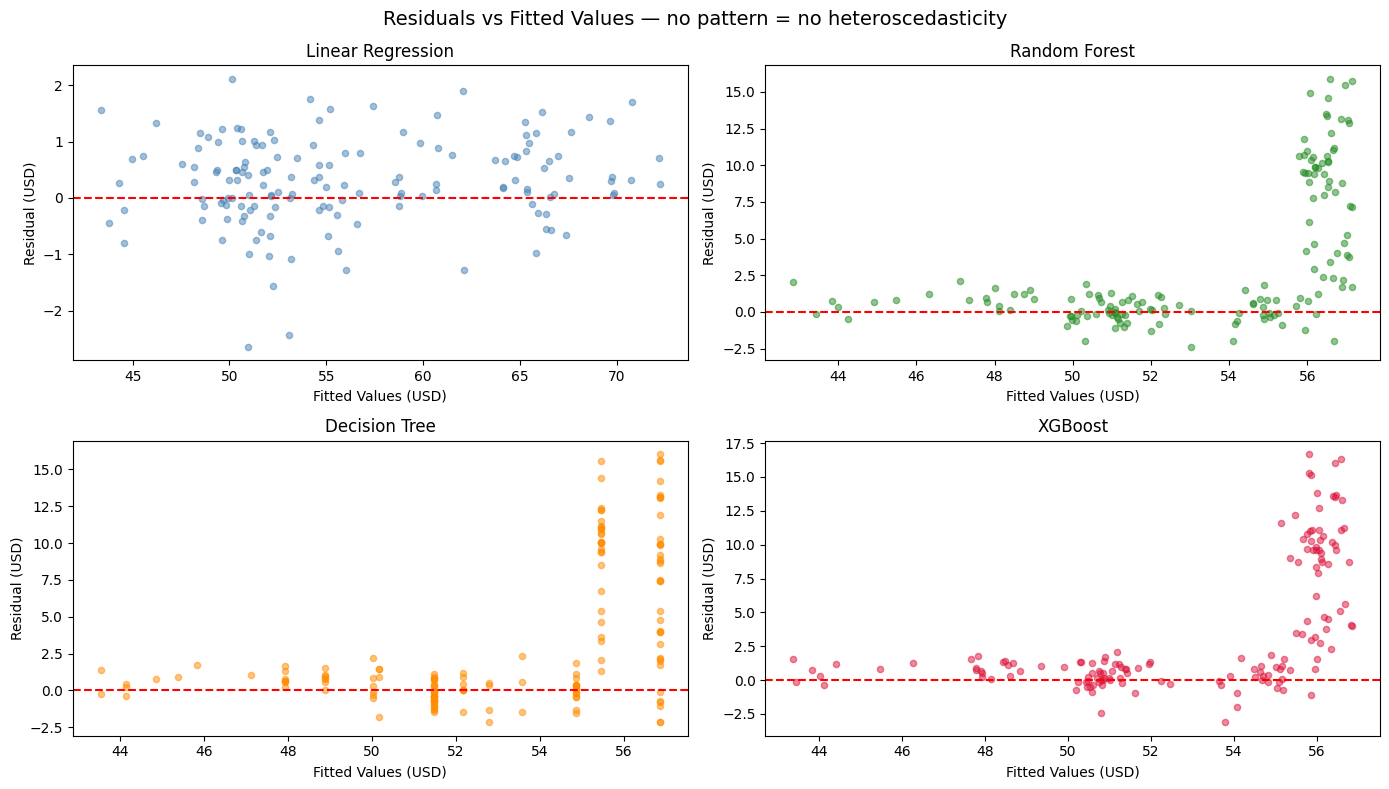

In [55]:
model_preds = [
    ('Linear Regression', lr_pred, 'steelblue'),
    ('Random Forest',     rf_pred, 'forestgreen'),
    ('Decision Tree',     dt_pred, 'darkorange'),
    ('XGBoost',           xgb_pred,'crimson'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, pred, color) in zip(axes.ravel(), model_preds):
    res = y_test.values - pred
    ax.hist(res, bins=20, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(0,          color='black', linestyle='--', linewidth=2)
    ax.axvline(np.mean(res), color='red', linestyle='-', linewidth=1.5,
               label=f'Mean = {np.mean(res):.2f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Prediction Error (USD)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Residual Distributions — centered near 0 = low bias', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, pred, color) in zip(axes.ravel(), model_preds):
    ax.scatter(pred, y_test.values - pred, alpha=0.5, s=20, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name}')
    ax.set_xlabel('Fitted Values (USD)')
    ax.set_ylabel('Residual (USD)')
plt.suptitle('Residuals vs Fitted Values — no pattern = no heteroscedasticity', fontsize=14)
plt.tight_layout()
plt.show()

## Section 11: Deep Learning — Sequence Preparation

**What this cell does:** Prepares **sliding-window sequences** for the RNN and LSTM models.

**Why RNN/LSTM need different data than tabular models:**
- Tabular models receive one row of 11 features per prediction
- RNNs/LSTMs are designed to process **ordered sequences** — they expect a 3D tensor: `(samples, timesteps, features)`
- Here: `LOOKBACK=30` means each input is the last 30 closing prices in order

**Scaling:** `MinMaxScaler` compresses prices to [0, 1] which helps neural network training converge. The scaler is fit on training prices only — predictions are inverse-transformed back to USD for evaluation.

**Note:** This creates a slightly different test set than the tabular models (30 rows shorter due to the lookback window), so MAE values are comparable in scale but not perfectly equivalent.

In [57]:
LOOKBACK = 30

price_arr   = df[[target_stock]].values
n_train_seq = int(len(price_arr) * 0.8)

seq_scaler = MinMaxScaler()
seq_scaler.fit(price_arr[:n_train_seq])
scaled_arr = seq_scaler.transform(price_arr)

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(scaled_arr)):
    X_seq.append(scaled_arr[i - LOOKBACK:i])
    y_seq.append(scaled_arr[i, 0])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split_seq = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

y_test_actual = seq_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()

print(f"Train sequences : {X_train_seq.shape}")
print(f"Test  sequences : {X_test_seq.shape}")
print(f"Each input  → shape ({LOOKBACK}, 1) = 30 days of closing prices")

NameError: name 'MinMaxScaler' is not defined

### 11a. Simple RNN (Recurrent Neural Network)

**How it works:** A Simple RNN processes the 30-day price sequence one step at a time. At each step, it updates a **hidden state** that summarizes what it has seen so far. The final hidden state is passed to dense layers for prediction.

**Architecture:** `SimpleRNN(64) → Dropout(0.2) → Dense(32) → Dense(1)`
- `Dropout(0.2)` randomly deactivates 20% of neurons during training to prevent overfitting
- `EarlyStopping` stops training if validation loss stops improving — prevents wasting time and overfitting

**Limitation:** Simple RNNs suffer from the *vanishing gradient problem* — they struggle to learn patterns from more than ~10–20 steps back. LSTM (next cell) solves this.

In [58]:
if not HAS_TF:
    print("TensorFlow not installed - skipping RNN.")
    rnn_pred = None
    rnn_mae  = np.nan
    rnn_r2   = np.nan
else:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)
    rnn_model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    rnn_model.compile(optimizer='adam', loss='mse')

    rnn_model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1, epochs=30, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    rnn_pred = seq_scaler.inverse_transform(
        rnn_model.predict(X_test_seq, verbose=0).reshape(-1, 1)
    ).ravel()

    rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)
    rnn_r2  = r2_score(y_test_actual, rnn_pred)
    print(f"RNN  MAE : {rnn_mae:.4f}")
    print(f"RNN  R2  : {rnn_r2:.4f}")

    plt.figure(figsize=(14, 5))
    plt.plot(y_test_actual, label='Actual', linewidth=3)
    plt.plot(rnn_pred, label='RNN', linestyle='--')
    plt.title(f'{target_stock} - RNN (30-Day Sliding Window)')
    plt.xlabel('Test Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

NameError: name 'X_train_seq' is not defined

### 11b. LSTM (Long Short-Term Memory)

**How it works:** LSTM extends the Simple RNN with three **gating mechanisms**:
- **Forget gate** — decides what information to discard from memory
- **Input gate** — decides what new information to store
- **Output gate** — decides what to output from memory

These gates allow LSTM to **selectively remember** patterns across many timesteps, solving the vanishing gradient problem. This makes LSTM better at capturing long-term price trends.

**Architecture:** `LSTM(64, return_sequences=True) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16) → Dense(1)`

The stacked LSTM layers allow the model to learn both **low-level** (daily fluctuations) and **high-level** (weekly trends) temporal patterns simultaneously.

In [59]:
if not HAS_TF:
    print("TensorFlow not installed - skipping LSTM.")
    lstm_pred = None
    lstm_mae  = np.nan
    lstm_r2   = np.nan
else:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)
    lstm_model = Sequential([
        LSTM(32, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(16, activation='tanh'),
        Dropout(0.2),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')

    lstm_model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1, epochs=30, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    lstm_pred = seq_scaler.inverse_transform(
        lstm_model.predict(X_test_seq, verbose=0).reshape(-1, 1)
    ).ravel()

    lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
    lstm_r2  = r2_score(y_test_actual, lstm_pred)
    print(f"LSTM  MAE : {lstm_mae:.4f}")
    print(f"LSTM  R2  : {lstm_r2:.4f}")

    plt.figure(figsize=(14, 5))
    plt.plot(y_test_actual, label='Actual', linewidth=3)
    plt.plot(lstm_pred, label='LSTM', linestyle='--')
    plt.title(f'{target_stock} - LSTM (30-Day Sliding Window)')
    plt.xlabel('Test Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

NameError: name 'X_train_seq' is not defined

## Section 12: Final Results

**What this cell does:** Combines all models into a single comparison chart and summary table.

**How to interpret the results:**
- The **top panel** shows all tabular models vs actual prices on the same test set
- The **bottom panel** shows RNN/LSTM on their sliding-window test set (same time period, slightly different boundary)
- In the table, green cells highlight the best value per column
- The naive baseline is the reference point — any model with higher MAE than baseline failed to add value

**Note:** `*` marks models using a 30-day sliding-window test set, which is not perfectly equivalent to the tabular test set.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].plot(y_test.values, label='Actual', linewidth=3, color='black')
axes[0].plot(naive_pred, label='Naive Baseline', linestyle=':', color='gray', alpha=0.8)
axes[0].plot(lr_pred,    label='Linear Regression', linestyle='--')
axes[0].plot(rf_pred,    label='Random Forest',     linestyle='--')
axes[0].plot(dt_pred,    label='Decision Tree',     linestyle='--')
axes[0].plot(xgb_pred,   label='XGBoost',           linestyle='--')
axes[0].set_title(f'{target_stock} — Tabular Models vs Actual')
axes[0].set_xlabel('Test Days')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True)

if rnn_pred is not None and lstm_pred is not None:
    axes[1].plot(y_test_actual, label='Actual', linewidth=3, color='black')
    axes[1].plot(rnn_pred,  label='RNN',  linestyle='--')
    axes[1].plot(lstm_pred, label='LSTM', linestyle='--')
    axes[1].set_title(f'{target_stock} — Sequential Models vs Actual (Sliding Window)')
else:
    axes[1].text(0.5, 0.5, 'TensorFlow not available — RNN/LSTM skipped',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title('Sequential Models (Skipped)')

axes[1].set_xlabel('Test Days')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'{target_stock} Stock Price Prediction — All Models', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
all_results = pd.DataFrame({
    'Model': [
        'Naive Baseline (Random Walk)',
        'Linear Regression',
        'Random Forest',
        'Decision Tree',
        'XGBoost',
        'RNN (30-day window) *',
        'LSTM (30-day window) *',
    ],
    'MAE (USD)': [
        naive_mae,
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        dt_mae, xgb_mae,
        rnn_mae  if rnn_pred  is not None else np.nan,
        lstm_mae if lstm_pred is not None else np.nan,
    ],
    'R² Score': [
        naive_r2,
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        dt_r2, xgb_r2,
        rnn_r2   if rnn_pred  is not None else np.nan,
        lstm_r2  if lstm_pred is not None else np.nan,
    ]
}).round(4)

print("* RNN/LSTM use a 30-day sliding-window test set (same period, slightly different boundary).\n")
all_results.style \
    .highlight_min(subset=['MAE (USD)'], color='lightgreen') \
    .highlight_max(subset=['R² Score'],  color='lightgreen')